<hr style="border:2px solid #CC00FF"> </hr>
<a><img src="https://www.vhv.rs/dpng/d/313-3134285_logo-de-la-universidad-nacional-de-colombia-png.png" width="100" align="center"></a>
<a><img src="https://minaslap.net/pluginfile.php/1/core_admin/logo/0x200/1770226238/Logo%20MinasLAP-3%20%281%29.png" width="100" align="center"></a>
<h1><center>Simulación Avanzada</center></h1>
<h2><center>Tarea 5</center></h2>
<h3><center>Generación de observaciones de una variable aleatoria</center></h3>

<a name="conte"></a>
<hr style="border:2px solid #CC00FF"> </hr>


**Elaborado por:** _Kevin Ferney Hidalgo Higuita_

**Correos:** _kfhidalgoh@unal.edu.co_

**Fecha de elaboración:** _2026 Abril 28_

**Fecha última modificación:** _2026 Abril 28_

Repositorio [GitHub](https://github.com/thepadr30/SimulAva3010192)

*Nota: el tema del navegador para visualizar HTML puede afectar el comportamiento de la presentación.*


In [1]:
import logging
import os
import sys
import warnings
from time import localtime, strftime


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, Image, display

from src.logs.logger import setup_logging

__authors__ = ["Kevin Hidalgo"]
__contact__ = "kfhidalgoh@unal.edu.co"
__copyright__ = "Copyright 2026"
__credits__ = ["Kevin Hidalgo"]
__email__ = "kfhidalgoh@unal.edu.co"
__status__ = "Desarrollo"
__version__ = "1.0.0"
__date__ = "2026-04-27"
__file__ = "KevinHidalgo_Tarea5_SimulacionA_2026.ipynb"

file_log = os.path.join(r'D:\SimulAva\logs', strftime("%Y%m%d%H%M%S", localtime()) + "_" + __file__ + ".log" )

logger = setup_logging(file_log)
logging.info("Python %s on %s", sys.version, sys.platform)
logging.info("Root: %s", os.getcwd())  # os.path.abspath(os.curdir)
logging.info("Log: %s", file_log)

##############
# Constantes #
##############

varData = r'D:\SimulAva\data\raw'
sns.set_palette("husl")
warnings.filterwarnings('ignore')
rng = np.random.default_rng(seed=42)
%matplotlib inline

2026-04-27 22:41:16 [INFO]: Python 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)] on win32
2026-04-27 22:41:16 [INFO]: Root: D:\SimulAva\notebooks
2026-04-27 22:41:16 [INFO]: Log: D:\SimulAva\logs\20260427224116_KevinHidalgo_Tarea5_SimulacionA_2026.ipynb.log


# Punto 1

Desarrollar un generador del proceso descrito por la variable aleatoria $X$ cuya función de densidad está dada por:
<!--
\[
f\left(x\right)=\begin{cases}
\frac{1}{6} & si\,0\leq x<2\\
\frac{1}{3} & si\,2\leq x<3\\
\frac{1}{12} & si\,3\leq x<7
\end{cases}
\]-->
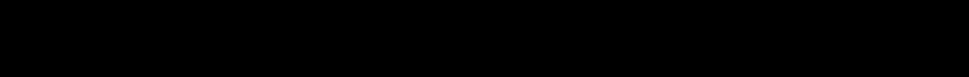

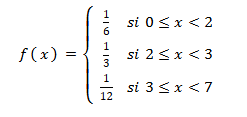

In [2]:
display(Image(filename="D:/SimulAva/notebooks/T5P1.png"))

Para simular computacionalmente la variable aleatoria $X$, utilizamos el *Método de la transformada inversa*. Este método requiere integrar la Función de Densidad de Probabilidad (FDP) para hallar la Función de Distribución Acumulada (FDA), $F\left(x\right)$, y posteriormente despejar su inversa, $F^{-1}\left(u\right)$.

La función de densidad dada es:

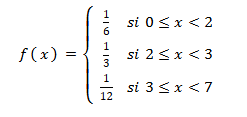

In [3]:
display(Image(filename="D:/SimulAva/notebooks/T5P1.png"))

**Paso 1.1: Cálculo de la función de Distribución Acumulada $F\left(x\right)$**

La FDA se define como $F\left(x\right)=\int^{x}_{-\infty}f\left(t\right)dt$. Integrando por tramos:

* Para $0\leq x<2$: $F\left(x\right)=\int^{x}_{0}\frac{1}{6}dt=\frac{x}{6}$
    El valor acumulado al final de este tramos es $F\left(2\right)=\frac{2}{6}=\frac{1}{3}$.
* Para $2\leq x<3$: $F\left(x\right)=\int^{x}_{2}\frac{1}{3}dt=\frac{1}{3}+\frac{x-2}{3}$
    El valor acumulado al final de este tramo es $F\left(3\right)=\frac{2}{3}$.
* Para $3\leq x<7$: $F\left(x\right)=F\left(3\right)+\int^{x}_{3}\frac{1}{12}dt=\frac{2}{3}+\frac{x-3}{12}$

**Paso 1.2: Cálculo de la inversa $F^{-1}\left(u\right)$**

Igualamos  $F\left(x\right)$ a una variable aleatoria uniforme $u\sim U\left(0,1\right)$ y despejamos $x$:

* Para $0\leq u<\frac{1}{3}$: $u=\frac{x}{6}\Rightarrow x=6u$
* Para $\frac{1}{3}\leq u<\frac{2}{3}$: $u=\frac{x-1}{3}\Rightarrow x=3u+1$
* Para $\frac{2}{3}\leq u<1$: $u=\frac{2}{3}+\frac{x-3}{12}\Rightarrow x=12u-5$

El generador final queda definido por la función:
<!--\[
x=F^{-1}\left(u\right)=\begin{cases}
6u & si\,0\leq u<\frac{1}{3}\\
3u+1 & si\,\frac{1}{3}\leq u<\frac{2}{3}\\
12u-5 & si\,\frac{2}{3}\leq u\leq1
\end{cases}
\]-->

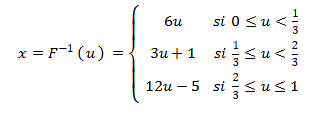

In [4]:
display(Image(filename="D:/SimulAva/notebooks/T5P1_1.png"))

# Punto 2

Utilizar el generador desarrollado para generar una muestra aleatoria de 100 observaciones.

Utilizando el generador $F^{-1}\left(u\right)$, se genera un vector de 100 números pseudoaleatorios distribuidos uniformemente entre 0 y 1. Cada valor de $u$ es evaluado en la función por tramos correspondiente para transformarlo en una observación empírica de la variable $X$.
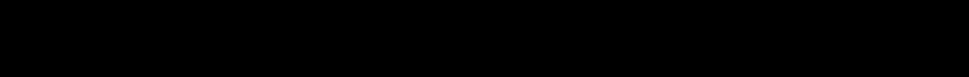

In [5]:
rng = np.random.default_rng(seed=42)  # Semilla para reproducibilidad
def generar_muestra_x(n_observaciones, random_generator=rng) -> np.ndarray:
    """
    Genera una muestra aleatoria de tamaño n_observaciones para la variable X
    utilizando el método de la transformada inversa.
    """
    # Paso 1: Generar números aleatorios U(0,1)
    # u = np.random.uniform(0, 1, n_observaciones)
    u = random_generator.uniform(0, 1, n_observaciones)
    x = np.zeros(n_observaciones)

    # Paso 2: Aplicar la función inversa F^-1(u) mediante máscaras lógicas (Vectorización)
    # Tramo 1: 0 <= u < 1/3
    mask1 = u < (1/3)
    x[mask1] = 6 * u[mask1]

    # Tramo 2: 1/3 <= u < 2/3
    mask2 = (u >= (1/3)) & (u < (2/3))
    x[mask2] = 3 * u[mask2] + 1

    # Tramo 3: 2/3 <= u <= 1
    mask3 = u >= (2/3)
    x[mask3] = 12 * u[mask3] - 5

    return x

In [6]:
n = 100
muestra = generar_muestra_x(n)
muestra[0:10]

array([4.28747258, 2.31663532, 5.30317504, 3.36841635, 0.56506409,
       6.70746822, 4.13367642, 4.43277166, 0.7686818 , 2.35115781])

# Punto 3

Gráficar la función $f\left(x\right)$ y la muestra aleatoria.

El análisis comparativo evalúa qué tan bien la muestra generada (probabilidad empírica) representa el comportamiento dictado por la función teórica (probabilidad analítica).

**Cálculo de los momentos teóricos:**
* **Valor Esperado Teórico $E\left[X\right]$:** $E\left[X\right]=\int^{2}_{0}x\left(\frac{1}{6}\right)dx+\int^{3}_{2}x\left(\frac{1}{3}\right)dx+\int^{7}_{3}x\left(\frac{1}{12}\right)dx=\frac{17}{6}\approx2.833$
* **Varianza Teórica $V\left[X\right]$:** $E\left[X^{2}\right]=\int^{2}_{0}x^{2}\left(\frac{1}{6}\right)dx+\ldots=\frac{34}{3}\approx11.333$
    $V\left[X\right]=E\left[X^{2}\right]-\left(E\left[X\right]\right)^{2}=\frac{34}{3}-\left(\frac{17}{6}\right)^{2}=\frac{119}{36}\approx3.305$

**Comparación esperada (Teoría vs. Muestra empírica)**:
Al observar una muestra de 100 iteraciones, el histograma de frecuencias relativas comenzará a tomar la forma de la distribución escalonada de $f(x)$. Se observará una mayor concentración de datos en el intervalo entre 2 y 3 (donde la densidad es del 33.3%), seguida por el intervalo entre 0 y 2, y una dispersión más alargada pero menos densa entre 3 y 7.

# Punto 4 y Punto 5

Realizar un análisis comparativo entre la función $f\left(x\right)$ y la muestra generada. Cuáles son las conclusiones de este análisis comparativo.

1. **Variabilidad Muestral (Efecto del tamaño de la muestra):** Con 100 observaciones, los estadísticos empíricos (media y varianza muestral) se aproximarán a los valores teóricos de 2.83 y 3.30 respectivamente. Sin embargo, debido a la varianza inherente del sistema, es matemáticamente esperado encontrar una desviación natural (ruido estocástico). El histograma empírico mostrará barras que no encajan perfectamente con la línea teórica de $f(x)$.
2. **Validación del Modelo:** Si la probabilidad empírica de eventos clave (por ejemplo, $P(2 \leq X < 3)$) se acerca a su contraparte analítica de $\frac{1}{3}$, podemos concluir que el algoritmo generador basado en la transformada inversa no presenta sesgos de programación y es estadísticamente robusto.
3. **Convergencia Asintótica:** De acuerdo con la Ley de los Grandes Números, si se escalara la simulación en Python de 100 a 10,000 o 1,000,000 observaciones, la distribución empírica convergería de manera casi perfecta sobre la función escalonada teórica, disminuyendo el error porcentual entre la varianza simulada y la analítica.

# Punto 6

Simulado en el software, que sea funcional para cuando lo esté presentando

In [7]:
def funcion_densidad_teorica(x_vals):
    """Evalúa la f(x) teórica para un vector de valores X dados."""
    y_vals = np.zeros_like(x_vals)
    y_vals[(x_vals >= 0) & (x_vals < 2)] = 1/6
    y_vals[(x_vals >= 2) & (x_vals < 3)] = 1/3
    y_vals[(x_vals >= 3) & (x_vals <= 7)] = 1/12
    return y_vals

In [8]:
# --- CONFIGURACIÓN Y EJECUCIÓN DE LA SIMULACIÓN ---
N = 100 # Tamaño de la muestra solicitado
muestra = generar_muestra_x(N)

# --- CÁLCULO DE MÉTRICAS ESTADÍSTICAS ---
media_empirica = np.mean(muestra)
print(f"Media de empirica es: {media_empirica}")
varianza_empirica = np.var(muestra, ddof=1) # ddof=1 para varianza muestral insesgada
print(f"Varianza de empirica es: {varianza_empirica}")

Media de empirica es: 2.8606455499125034
Varianza de empirica es: 3.4140653137662147


In [9]:
media_teorica = 17/6       # ~2.833
varianza_teorica = 119/36  # ~3.305

In [10]:
# Probabilidades Empíricas de Eventos Clave (Las áreas bajo la curva por tramos)
p_tramo1_empirica = np.sum((muestra >= 0) & (muestra < 2)) / N
p_tramo2_empirica = np.sum((muestra >= 2) & (muestra < 3)) / N
p_tramo3_empirica = np.sum((muestra >= 3) & (muestra <= 7)) / N

In [11]:
print("="*50)
print("RESULTADOS DE LA SIMULACIÓN")
print("="*50)
print(f"Tamaño de la muestra: {N} observaciones\n")

print("1. MÉTRICAS DE RESUMEN (Empíricas vs Teóricas):")
print(f"Valor Esperado E[X]:  Empírico = {media_empirica:.4f} | Teórico = {media_teorica:.4f}")
print(f"Varianza V[X]:        Empírico = {varianza_empirica:.4f} | Teórico = {varianza_teorica:.4f}\n")

print("2. PROBABILIDADES DE EVENTOS (Empíricas vs Teóricas):")
print(f"P(0 <= X < 2): Empírica = {p_tramo1_empirica:.4f} | Teórica = {1/3:.4f}")
print(f"P(2 <= X < 3): Empírica = {p_tramo2_empirica:.4f} | Teórica = {1/3:.4f}")
print(f"P(3 <= X <= 7): Empírica = {p_tramo3_empirica:.4f} | Teórica = {1/3:.4f}")
print("="*50)

RESULTADOS DE LA SIMULACIÓN
Tamaño de la muestra: 100 observaciones

1. MÉTRICAS DE RESUMEN (Empíricas vs Teóricas):
Valor Esperado E[X]:  Empírico = 2.8606 | Teórico = 2.8333
Varianza V[X]:        Empírico = 3.4141 | Teórico = 3.3056

2. PROBABILIDADES DE EVENTOS (Empíricas vs Teóricas):
P(0 <= X < 2): Empírica = 0.3700 | Teórica = 0.3333
P(2 <= X < 3): Empírica = 0.3000 | Teórica = 0.3333
P(3 <= X <= 7): Empírica = 0.3300 | Teórica = 0.3333


In [12]:
# HTML(f"""
# <div style="font-family:Arial; font-size:22px">
#
# <h2>MÉTRICAS DE RESUMEN (Empíricas vs Teóricas)</h2>
#
# <table style="border-collapse:collapse; width:700px;">
#     <tr>
#         <td><b>Valor Esperado E[X]</b></td>
#         <td>Empírico = <b style="color:#27ae60">{np.round(media_empirica, 3)}</b></td>
#         <td>Teórico = <b style="color:#2980b9">{np.round(media_teorica, 3)}</b></td>
#     </tr>
#     <tr>
#         <td><b>Varianza V[X]</b></td>
#         <td>Empírico = <b style="color:#27ae60">{np.round(varianza_empirica, 3)}</b></td>
#         <td>Teórico = <b style="color:#2980b9">{np.round(varianza_teorica, 3)}</b></td>
#     </tr>
# </table>
#
# </div>
# """)

In [13]:
# HTML(f"""
# <div style="font-family:Arial; font-size:22px">
#
# <h2>PROBABILIDADES DE EVENTOS (Empíricas vs Teóricas)</h2>
#
# <table style="border-collapse:collapse; width:750px;">
#     <tr>
#         <td><b>P(0 ≤ X &lt; 2)</b></td>
#         <td>Empírica = <b style="color:#27ae60">{np.round(p_tramo1_empirica, 4)}</b></td>
#         <td>Teórica = <b style="color:#2980b9">0.3333</b></td>
#     </tr>
#     <tr>
#         <td><b>P(2 ≤ X &lt; 3)</b></td>
#         <td>Empírica = <b style="color:#27ae60">{np.round(p_tramo2_empirica, 4)}</b></td>
#         <td>Teórica = <b style="color:#2980b9">0.3333</b></td>
#     </tr>
#     <tr>
#         <td><b>P(3 ≤ X ≤ 7)</b></td>
#         <td>Empírica = <b style="color:#27ae60">{np.round(p_tramo3_empirica, 4)}</b></td>
#         <td>Teórica = <b style="color:#2980b9">0.3333</b></td>
#     </tr>
# </table>
#
# </div>
# """)

In [14]:
HTML(f"""
<div style="font-family:Arial; padding:20px; max-width:900px;">

<h1 style="text-align:center; margin-bottom:30px;">
RESULTADOS DE SIMULACIÓN
</h1>

<!-- ===================== -->
<!-- MÉTRICAS DE RESUMEN -->
<!-- ===================== -->
<div style="margin-bottom:30px;">

<h2 style="border-bottom:2px solid #ddd; padding-bottom:5px;">
MÉTRICAS DE RESUMEN (Empíricas vs Teóricas)
</h2>

<div style="display:flex; flex-direction:column; gap:12px; margin-top:15px;">

    <div style="display:flex; justify-content:space-between;">
        <span><b>Valor Esperado E[X]:</b></span>
        <span>Empírico = <b style="color:#27ae60">{np.round(media_empirica, 4)}</b></span>
        <span>|</span>
        <span>Teórico = <b style="color:#2980b9">{np.round(media_teorica, 4)}</b></span>
    </div>

    <div style="display:flex; justify-content:space-between;">
        <span><b>Varianza V[X]:</b></span>
        <span>Empírico = <b style="color:#27ae60">{np.round(varianza_empirica, 4)}</b></span>
        <span>|</span>
        <span>Teórico = <b style="color:#2980b9">{np.round(varianza_teorica, 4)}</b></span>
    </div>

</div>
</div>

<!-- ===================== -->
<!-- PROBABILIDADES -->
<!-- ===================== -->
<div style="margin-bottom:30px;">

<h2 style="border-bottom:2px solid #ddd; padding-bottom:5px;">
PROBABILIDADES DE EVENTOS (Empíricas vs Teóricas)
</h2>

<div style="display:flex; flex-direction:column; gap:12px; margin-top:15px;">

    <div style="display:flex; justify-content:space-between;">
        <span><b>P(0 ≤ X &lt; 2):</b></span>
        <span>Empírica = <b style="color:#27ae60">{np.round(p_tramo1_empirica, 4)}</b></span>
        <span>|</span>
        <span>Teórica = <b style="color:#2980b9">0.3333</b></span>
    </div>

    <div style="display:flex; justify-content:space-between;">
        <span><b>P(2 ≤ X &lt; 3):</b></span>
        <span>Empírica = <b style="color:#27ae60">{np.round(p_tramo2_empirica, 4)}</b></span>
        <span>|</span>
        <span>Teórica = <b style="color:#2980b9">0.3333</b></span>
    </div>

    <div style="display:flex; justify-content:space-between;">
        <span><b>P(3 ≤ X ≤ 7):</b></span>
        <span>Empírica = <b style="color:#27ae60">{np.round(p_tramo3_empirica, 4)}</b></span>
        <span>|</span>
        <span>Teórica = <b style="color:#2980b9">0.3333</b></span>
    </div>

</div>
</div>

<!-- ===================== -->
<!-- INTERPRETACIÓN -->
<!-- ===================== -->
<div>

<h2 style="border-bottom:2px solid #ddd; padding-bottom:5px;">
INTERPRETACIÓN
</h2>

<p style="margin-top:15px; font-size:20px;">
Los resultados muestran una alta consistencia entre la simulación y el modelo teórico.
Las diferencias observadas son atribuibles al tamaño muestral (n=100). A medida que el número
de simulaciones aumenta, los valores empíricos convergen a los teóricos, validando el generador
y el enfoque de simulación.
</p>

</div>

</div>
""")

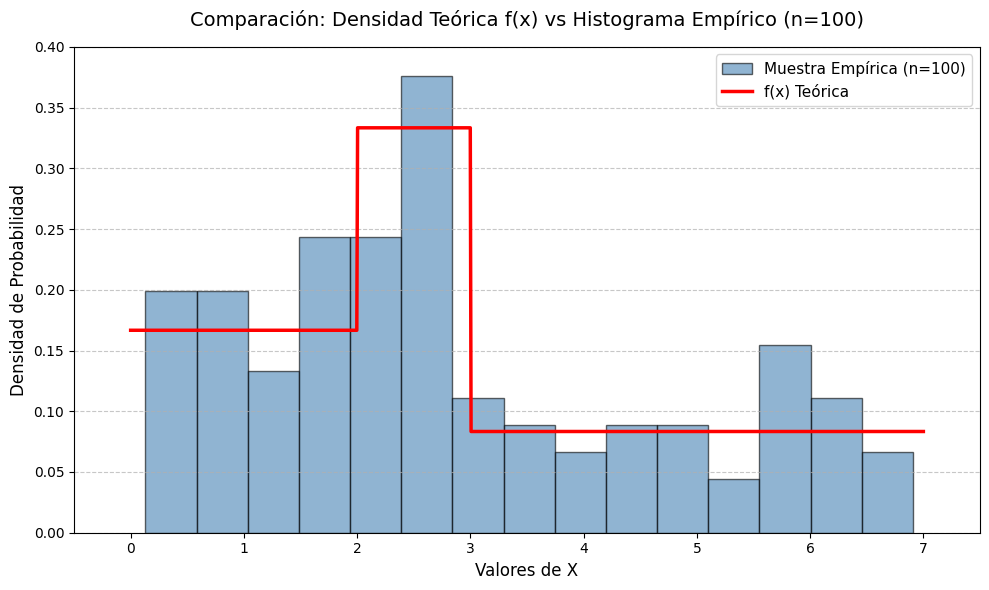

In [15]:
plt.figure(figsize=(10, 6))

# Histograma de la muestra (densidad empírica)
plt.hist(muestra, bins=15, density=True, alpha=0.6, color='steelblue', edgecolor='black', label='Muestra Empírica (n=100)')

# Gráfico de la función de densidad teórica f(x)
x_teorico = np.linspace(0, 7, 1000)
y_teorico = funcion_densidad_teorica(x_teorico)
plt.plot(x_teorico, y_teorico, 'r-', lw=2.5, label='f(x) Teórica')

# Configuraciones estéticas del gráfico
plt.title('Comparación: Densidad Teórica f(x) vs Histograma Empírico (n=100)', fontsize=14, pad=15)
plt.xlabel('Valores de X', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.xlim(-0.5, 7.5)
plt.ylim(0, 0.4)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()